In [1]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path

In [2]:
import pandas as pd

## Function to find red and green point

In [3]:
# HSV ranges (OpenCV scale: H 0-179, S/V 0-255) as lists of (lower, upper) pairs.
# Red wraps around the hue axis, so it needs two ranges.
COLOR_RANGES = {
    "red": [
        ((0, 80, 50), (10, 255, 255)),
        ((170, 80, 50), (180, 255, 255)),
    ],
    "green": [
        ((35, 80, 50), (85, 255, 255)),
    ],
}


def detect_point(frame, color="red", annotated=None):
    """
    Detect the largest blob of the given color in the frame and return its centroid (x, y).

    Parameters:
        frame: BGR image.
        color: "red" or "green" (any key of COLOR_RANGES).
        annotated: optional image to draw on (e.g. the output of a previous
            detect_point call) so several colors end up in one annotated frame.
            If None, a copy of `frame` is used.
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no object of that color is detected.
    """
    if color not in COLOR_RANGES:
        raise ValueError(
            f"Unsupported color '{color}'. Choose from: {list(COLOR_RANGES)}"
        )

    if annotated is None:
        annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in COLOR_RANGES[color]:
        mask = cv2.bitwise_or(
            mask, cv2.inRange(hsv, np.array(lower), np.array(upper))
        )

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"{color} ({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [4]:
# Function to process video and track colored points
def process_video(video_path, output_csv, preview=True, save_annotated=False, colors=("red", "green")):
    """
    Track one point per color in `colors`. The CSV has the columns
    frame, time_s, <color>_x, <color>_y for each color, in the given order.
    The same data is returned as a pandas DataFrame.
    """
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(video_path.stem + "_tracked.mp4")
        writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        time_s = frame_idx / fps if fps > 0 else np.nan
        row = {"frame": frame_idx, "time_s": time_s}

        annotated = None
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        for color in colors:
            x, y, color_mask, annotated = detect_point(frame, color, annotated)
            row[f"{color}_x"] = x
            row[f"{color}_y"] = y
            mask = cv2.bitwise_or(mask, color_mask)

        results.append(row)

        if writer is not None:
            writer.write(annotated)

        if preview:
            combined_mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
            top = np.hstack((frame, annotated))
            bottom = np.hstack((combined_mask, np.zeros_like(combined_mask)))
            display = np.vstack((top, bottom))

            scale = 0.4
            display = cv2.resize(display, None, fx=scale, fy=scale)

            cv2.imshow("Original | Annotated / Mask", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()

    coord_cols = [f"{c}_{axis}" for c in colors for axis in ("x", "y")]
    df = pd.DataFrame(results).astype({col: float for col in coord_cols})
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")
    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    print(f"Frames processed: {len(df)}")
    for color in colors:
        missing = df[f"{color}_x"].isna().sum()
        print(f"Frames with missing {color} detection: {missing}")

    return df

In [5]:
# Function to export the first frame of a video as a PNG image
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [6]:
# export_first_frame(
#     video_path=video,
#     output_png="20260710_141408_first_frame.png",
#     dpi=300
# )

In [7]:
# The notebook lives in notebooks/, the videos in <project root>/videos
root = Path.cwd() if (Path.cwd() / "videos").exists() else Path.cwd().parent
video = root / "videos" / "30_A.mp4"
output = root / "videos" / "30_A.csv"

res = process_video(
    video_path=video,
    output_csv=output,
    preview=True,
    save_annotated=True
)


Done. Saved coordinates to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_A.csv
Saved annotated video to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_A_tracked.mp4
Frames processed: 324
Frames with missing red detection: 66
Frames with missing green detection: 4


In [8]:
# desplaying row 0
res

,frame,time_s,red_x,red_y,green_x,green_y
0,0,0.000000,1180.0,403.0,1268.0,685.0
1,1,0.033328,1180.0,403.0,1268.0,685.0
2,2,0.066656,1180.0,403.0,1268.0,685.0
3,3,0.099984,1180.0,403.0,1268.0,684.0
4,4,0.133312,1180.0,403.0,1269.0,684.0
...,...,...,...,...,...,...
319,319,10.631649,1028.0,450.0,1022.0,757.0
320,320,10.664977,1027.0,452.0,1020.0,757.0
321,321,10.698305,NaN,NaN,1019.0,757.0
322,322,10.731633,NaN,NaN,1018.0,757.0


In [9]:
#function to convert pixel coordinates to meters
def pixels_to_m(x_pixel, y_pixel, scale, origin_x, origin_y):
    """
    Convert pixel coordinates to meters.

    Parameters:
    x_pixel (float): x coordinate in pixels
    y_pixel (float): y coordinate in pixels
    scale (float): scale factor (pixels per meter)
    origin_x (float): x coordinate of the origin in pixels
    origin_y (float): y coordinate of the origin in pixels

    Returns:
    (float, float): coordinates in meters
    """
    x_m = (x_pixel - origin_x) / scale
    y_m = -(y_pixel - origin_y) / scale # y points upward
    return x_m, y_m

In [10]:
# Calculating scale
# Assuming we know the real-world distance between two points in meters and their pixel coordinates
real_distance_m = 25.3e-2  # meters
x1_pixel = 963  #  pixel coordinates of the first point
y1_pixel = 156  #  pixel coordinates of the first point
x2_pixel = 1270  #  pixel coordinates of the second point
y2_pixel = 619  # pixel coordinates of the second point
pixel_distance = ((x2_pixel - x1_pixel)**2 + (y2_pixel - y1_pixel)**2)**0.5
scale = pixel_distance / real_distance_m
scale

2195.7864717736006

In [11]:
def cut_video(result, first_frame, last_frame=None):
    """
    Cut a video to include only frames from first_frame to last_frame.

    Parameters:
    result : Pandas dataframe as returned by the function process_video.
    first_frame (int): Index of the first frame to keep.
    last_frame (int, optional): Index of the last frame to keep. If None, keep until the end.

    Returns:
    Modified Pandas dataframe..
    """
    mask = result["frame"] >= first_frame
    if last_frame is not None:
        mask &= result["frame"] <= last_frame

    return result.loc[mask].reset_index(drop=True)

In [12]:
# cut_result = cut_video(res, 22)

# cut_result

In [32]:
def analyze_video(result, first_frame, last_frame=None, scale=scale, origin_x=0, origin_y=0, max_gap_frames=5,
                  m_red=270.5e-3, m_green=200.2e-3, L_red=12.9e-2, L_green=7e-2):
    """
    m_red, m_green: masses (kg); L_red, L_green: lengths (m) of the first and second rod.
    max_gap_frames: gaps of at most this many consecutive missing frames are filled by
    PCHIP interpolation (against time_s); longer gaps stay NaN. None disables interpolation.
    """
    # creating  a copy  of result to work with
    result = result.copy()
    cut_result = cut_video(result, first_frame, last_frame)
    # Addding columns which show x and y coordinates for red and green dots in meters
    result_with_m = cut_result.copy()
    # Shift time so that the first frame of the cut is at t = 0
    result_with_m["time_s"] = result_with_m["time_s"] - result_with_m["time_s"].min()
    for color in ("red", "green"):
        x_m, y_m = pixels_to_m(
            cut_result[f"{color}_x"], cut_result[f"{color}_y"], scale, origin_x, origin_y
        )
        result_with_m[f"{color}_x_m"] = x_m
        result_with_m[f"{color}_y_m"] = y_m

    # Fill short gaps in the coordinates (not in the angles, which can wrap around at +-pi)
    coord_cols = [f"{c}_{axis}_m" for c in ("red", "green") for axis in ("x", "y")]
    if max_gap_frames is None:
        interpolated = result_with_m[coord_cols]
    else:
        coords = result_with_m.set_index("time_s")[coord_cols]
        interpolated = coords.interpolate(method="pchip", limit_area="inside")
        for col in coord_cols:
            # Length of the run of missing values each NaN belongs to; leave long gaps unfilled
            missing = coords[col].isna()
            gap_length = missing.groupby((~missing).cumsum()).transform("sum")
            interpolated.loc[missing & (gap_length > max_gap_frames), col] = np.nan
    for col in coord_cols:
        result_with_m[f"{col[:-2]}_m_interpolated"] = interpolated[col].to_numpy()

    # Angle (radians) of the red dot measured from the vertical (y) axis
    result_with_m["phi_red"] = np.arctan2(
        result_with_m["red_x_m_interpolated"], -result_with_m["red_y_m_interpolated"]
    )
    # Angle (radians) of the green dot relative to the red dot, measured from the vertical (y) axis
    result_with_m["phi_green"] = np.arctan2(
        result_with_m["green_x_m_interpolated"] - result_with_m["red_x_m_interpolated"],
        -result_with_m["green_y_m_interpolated"] + result_with_m["red_y_m_interpolated"],
    )

    # Angular velocities (rad/s) by central differences. Unwrap first so that the jump at +-pi
    # does not show up as a spike; NaNs are skipped and stay NaN (np.gradient spreads them to neighbours).
    time = result_with_m["time_s"].to_numpy()
    for color in ("red", "green"):
        phi = result_with_m[f"phi_{color}"].to_numpy()
        valid = ~np.isnan(phi)
        phi_unwrapped = np.full_like(phi, np.nan)
        phi_unwrapped[valid] = np.unwrap(phi[valid])
        result_with_m[f"omega_{color}"] = np.gradient(phi_unwrapped, time)

    # Generalized momentum of the red point
    cos_phi_diff = np.cos(result_with_m["phi_red"] - result_with_m["phi_green"])
    result_with_m["p_red"] = (
        (m_red + m_green) * L_red**2 * result_with_m["omega_red"]
        + m_green * L_green * L_red * result_with_m["omega_green"] * cos_phi_diff
    )

    # Generalized momentum of the green point
    result_with_m["p_green"] = (
        m_green * L_green**2 * result_with_m["omega_green"]
        + m_green * L_green * L_red * result_with_m["omega_red"] * cos_phi_diff
    )

    return result_with_m

In [ ]:
import matplotlib.pyplot as plt


def plot_results(analyzed_result):
    """Plot the angles phi_red and phi_green as a function of time_s."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(analyzed_result["time_s"], analyzed_result["phi_red"], "r.", label="phi_red")
    ax.plot(analyzed_result["time_s"], analyzed_result["phi_green"], "g.", label="phi_green")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("angle (rad)")
    ax.set_title("Pendulum angles")
    ax.grid(True)
    ax.legend()
    plt.show()

In [ ]:
#Analyze the 30A angle
analyzed_result = analyze_video(res, 22, scale=scale, origin_x=1025, origin_y=156)
analyzed_result

,frame,time_s,red_x,red_y,green_x,green_y,red_x_m,red_y_m,green_x_m,green_y_m,red_x_m_interpolated,red_y_m_interpolated,green_x_m_interpolated,green_y_m_interpolated,phi_red,phi_green,omega_red,omega_green,p_red,p_green
0,22,0.000000,1183.0,401.0,1274.0,681.0,0.071956,-0.111577,0.113399,-0.239094,0.071956,-0.111577,0.113399,-0.239094,0.572780,0.314232,0.142421,0.096820,0.001285,0.000344
1,23,0.033328,1184.0,400.0,1276.0,680.0,0.072411,-0.111122,0.114310,-0.238639,0.072411,-0.111122,0.114310,-0.238639,0.577527,0.317459,0.099415,0.080741,0.000920,0.000253
2,24,0.066656,1184.0,399.0,1277.0,680.0,0.072411,-0.110666,0.114765,-0.238639,0.072411,-0.110666,0.114765,-0.238639,0.579407,0.319614,0.043078,0.064387,0.000450,0.000138
3,25,0.099984,1185.0,400.0,1278.0,679.0,0.072867,-0.111122,0.115221,-0.238183,0.072867,-0.111122,0.115221,-0.238183,0.580398,0.321751,0.014873,0.080399,0.000257,0.000105
4,26,0.133312,1185.0,400.0,1279.0,679.0,0.072867,-0.111122,0.115676,-0.238183,0.072867,-0.111122,0.115676,-0.238183,0.580398,0.324973,0.028276,0.048343,0.000306,0.000097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,319,9.898431,1028.0,450.0,1022.0,757.0,0.001366,-0.133893,-0.001366,-0.273706,0.001366,-0.133893,-0.001366,-0.273706,0.010204,-0.019541,0.050853,-0.245558,-0.000045,-0.000149
298,320,9.931760,1027.0,452.0,1020.0,757.0,0.000911,-0.134804,-0.002277,-0.273706,0.000911,-0.134804,-0.002277,-0.273706,0.006757,-0.022947,-0.120218,-0.035683,-0.001006,-0.000252
299,321,9.965088,NaN,NaN,1019.0,757.0,NaN,NaN,-0.002733,-0.273706,0.000297,-0.135527,-0.002733,-0.273706,0.002190,-0.021920,-0.151919,0.046642,-0.001106,-0.000229
300,322,9.998416,NaN,NaN,1018.0,757.0,NaN,NaN,-0.003188,-0.273706,-0.000459,-0.136152,-0.003188,-0.273706,-0.003370,-0.019838,-0.182881,0.229169,-0.001018,-0.000106


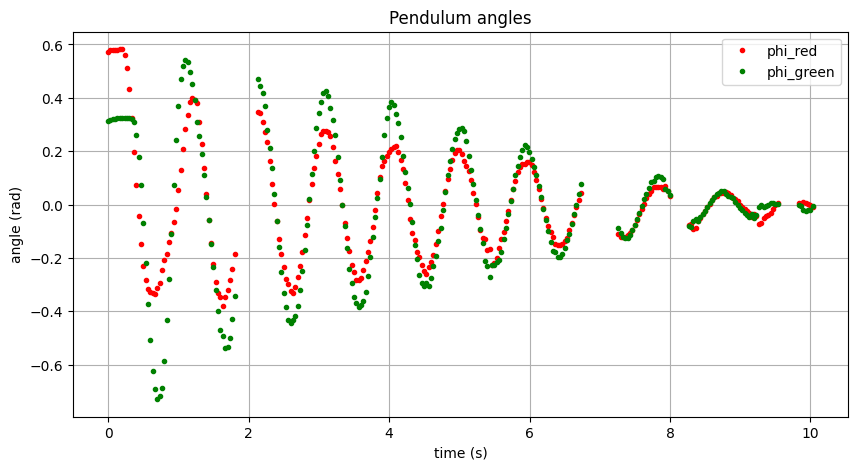

In [34]:
# plot the angles phi_red and phi_green of the red and green dots as a function of time_s
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(analyzed_result["time_s"], analyzed_result["phi_red"], "r.", label="phi_red")
ax.plot(analyzed_result["time_s"], analyzed_result["phi_green"],"g.", label="phi_green")
ax.set_xlabel("time (s)")
ax.set_ylabel("angle (rad)")
ax.set_title("Pendulum angles")
ax.grid(True)
ax.legend()
plt.show()

In [ ]:
# analyzing video 30B
video = root / "videos" / "30_B.mp4"
output = root / "videos" / "30_B.csv"

res_30B = process_video(
    video_path=video,
    output_csv=output,
    preview=True,
    save_annotated=True
)



Done. Saved coordinates to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_B.csv
Saved annotated video to: c:\Users\alesj\OneDrive - Delft University of Technology\onderzoekspracticum\double pendulum\data analysis\videos\30_B_tracked.mp4
Frames processed: 343
Frames with missing red detection: 102
Frames with missing green detection: 5


In [37]:
analyzed_result_30B = analyze_video(res_30B, 20,scale=scale)
analyzed_result_30B

,frame,time_s,red_x,red_y,green_x,green_y,red_x_m,red_y_m,green_x_m,green_y_m,red_x_m_interpolated,red_y_m_interpolated,green_x_m_interpolated,green_y_m_interpolated,phi_red,phi_green,omega_red,omega_green,p_red,p_green
0,20,0.000000,1177.0,403.0,1265.0,685.0,0.536027,-0.183533,0.576103,-0.311961,0.536027,-0.183533,0.576103,-0.311961,1.240912,0.302481,0.000000,0.096860,0.000103,0.000095
1,21,0.033328,1177.0,403.0,1266.0,685.0,0.536027,-0.183533,0.576559,-0.311961,0.536027,-0.183533,0.576559,-0.311961,1.240912,0.305709,-0.007495,0.015177,-0.000042,0.000007
2,22,0.066656,1178.0,404.0,1266.0,685.0,0.536482,-0.183989,0.576559,-0.311961,0.536482,-0.183989,0.576559,-0.311961,1.240412,0.303493,0.026959,-0.081923,0.000123,-0.000051
3,23,0.099984,1181.0,402.0,1268.0,683.0,0.537848,-0.183078,0.577470,-0.311050,0.537848,-0.183078,0.577470,-0.311050,1.242709,0.300248,0.064942,-0.097438,0.000405,-0.000027
4,24,0.133312,1183.0,400.0,1269.0,681.0,0.538759,-0.182167,0.577925,-0.310139,0.538759,-0.182167,0.577925,-0.310139,1.244741,0.296998,0.030488,-0.015035,0.000223,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,338,10.598311,NaN,NaN,1021.0,757.0,NaN,NaN,0.464981,-0.344751,NaN,NaN,0.464981,-0.344751,NaN,NaN,NaN,NaN,NaN,NaN
319,339,10.631639,NaN,NaN,1020.0,757.0,NaN,NaN,0.464526,-0.344751,NaN,NaN,0.464526,-0.344751,NaN,NaN,NaN,NaN,NaN,NaN
320,340,10.664967,NaN,NaN,1020.0,757.0,NaN,NaN,0.464526,-0.344751,NaN,NaN,0.464526,-0.344751,NaN,NaN,NaN,NaN,NaN,NaN
321,341,10.698295,NaN,NaN,1021.0,757.0,NaN,NaN,0.464981,-0.344751,NaN,NaN,0.464981,-0.344751,NaN,NaN,NaN,NaN,NaN,NaN
